## Feature Engineering: Sentinel-1 SAR Radar Analysis

In the context of the **Valdeorras forest**, traditional optical satellites (like Sentinel-2) are often hindered by the persistent cloud cover of Galicia. To ensure a continuous weekly monitoring system, we utilize **Sentinel-1 Synthetic Aperture Radar (SAR)** data. 

Radar waves penetrate clouds and smoke, allowing us to measure the physical properties of the terrain and vegetation regardless of weather conditions.

We process over **200,000 pixels per week** using the following features:


| Feature | Technical Name | Physical Interpretation |
| :--- | :--- | :--- |
| **VV (dB)** | Vertical-Vertical | **Soil Moisture:** Bounces mainly off the bare ground. Indicates if the soil is saturated or dry. |
| **VH (dB)** | Vertical-Horizontal | **Vegetation Stress:** Scatters through leaves and branches. Indicates biomass and internal water content of the plant. |
| **VH/VV Ratio** | Cross-Pol Ratio | **The "Forest Stethoscope":** Isolates vegetation health by canceling out topographic noise (mountain slopes). |

### SPEI (Standardised Precipitation-Evapotranspiration Index)
The **SPEI** is our "ground truth" for drought. It measures the climatic water balance (Rainfall minus Evapotranspiration).

*   **Positive Values (>0):** **Wet conditions.** Surplus of water, healthy ecosystem.
*   **Negative Values (<0):** **Drought conditions.** Water deficit and high hydric stress.
*   **Why spei01?** We use the 1-month scale to detect **Flash Droughts**—sudden, intense dry spells that rapidly turn the forest into a high-risk wildfire zone.

### Why this is critical for Machine Learning (XGBoost)

1. **Decibel Conversion (dB):** We convert raw linear backscatter to a logarithmic scale (dB). This stabilizes the variance and helps the Gradient Boosting trees find non-linear thresholds more efficiently.
2. **Topographic Normalization:** In the rugged geography of Valdeorras, the same forest looks different depending on the slope. The **VH/VV Ratio** acts as a "normalization" factor, ensuring the model learns about **Water Content** and not just the shape of the mountains.
3. **Pre-Drought Detection:** While optical indices (NDVI) only show damage once leaves turn brown, SAR detects the loss of **internal dielectric constant** (water) inside the stems and leaves weeks before it's visible.

> **Key Insight:** This radar-based approach provides a "Cloud-Free" competitive advantage, ensuring our system remains operational in the exact weather conditions (cloudy/rainy transitions) where flash droughts and floods begin to form.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

df_spei = pd.read_csv('../data/raw/-7.250000_42.250000_spei.csv', sep=';')
df_s1 = pd.read_csv('../data/raw/sentinel1.csv')

print("Datos cargados. Primeras filas de Sentinel-1:")
display(df_s1.head(10))
print("Primeras filas de SPEI:")
display(df_spei.head(10))

Datos cargados. Primeras filas de Sentinel-1:


,Zona,Fecha,VV_linear,VH_linear,Píxeles_Válidos,VV_dB,VH_dB,VH_VV_Ratio
0,Valdeorras_Incendio,2016-01-01,0.155205,0.039918,202500,-8.090940,-13.988277,-5.897337
1,Valdeorras_Incendio,2016-01-08,0.149043,0.038938,202500,-8.266889,-14.096224,-5.829335
2,Valdeorras_Incendio,2016-01-15,0.152006,0.037540,202500,-8.181405,-14.255075,-6.073670
3,Valdeorras_Incendio,2016-01-22,0.140401,0.036611,202500,-8.526311,-14.363922,-5.837611
4,Valdeorras_Incendio,2016-01-29,0.146038,0.036644,202500,-8.355347,-14.360016,-6.004669
5,Valdeorras_Incendio,2016-02-05,0.143383,0.036612,202500,-8.435026,-14.363748,-5.928722
6,Valdeorras_Incendio,2016-02-12,0.185399,0.048136,202500,-7.318936,-13.175335,-5.856399
7,Valdeorras_Incendio,2016-02-19,0.154351,0.043465,202500,-8.114895,-13.618652,-5.503757
8,Valdeorras_Incendio,2016-02-26,0.139403,0.036832,202500,-8.557294,-14.337713,-5.780419
9,Valdeorras_Incendio,2016-03-04,0.158352,0.038827,202500,-8.003752,-14.108625,-6.104874


Primeras filas de SPEI:


,dates,spei01
0,2016-01-16,1.9
1,2016-02-15,1.1
2,2016-03-16,0.5
3,2016-04-16,1.6
4,2016-05-16,0.7
5,2016-06-16,-1.2
6,2016-07-16,-1.2
7,2016-08-16,-1.9
8,2016-09-16,-0.8
9,2016-10-16,-0.7


##  Temporal Integration: Aligning Radar to Climate

To train the **XGBoost** model, we must synchronize the weekly satellite data with the monthly climate records from Sentinel-1. This process involves a **Temporal Downsampling** through monthly mean aggregation.

###  Handling "Speckle Noise"
Radar data is inherently "noisy" due to a phenomenon called **Speckle**—a grainy, salt-and-pepper interference caused by the coherent processing of backscattered signals. 
*   **The Solution:** By calculating the **monthly mean**, we act as a **temporal low-pass filter**. This smooths out random spikes (noise) and focuses the model on the biological trend.

###  Why the Monthly Mean is the Optimal Strategy?
1. **Biological Response Time:** Vegetation does not react to drought in a single day. Forests show "cumulative stress." A monthly average captures the **sustained hydric health** better than a single weekly snapshot.
2. **Signal-to-Noise Ratio (SNR):** Averaging the 4-5 weekly passes of Sentinel-1 into one monthly value increases the reliability of the data, ensuring the model learns **long-term trends** instead of sensor glitches or daily weather anomalies.
3. **Scale Matching:** Since the **SPEI-01** represents a monthly hydric balance, providing the model with a monthly "Radar Vigor" ensures that both the features and the target speak the same temporal language.

> **Engineering Note:** While we lose "high-frequency" precision, we gain **predictive stability**.


In [5]:
print("2. Alineando y fusionando datos temporalmente.")

# Formatear fechas a Mes-Año para poder cruzarlas
df_spei['Fecha'] = pd.to_datetime(df_spei['dates'])
df_spei['Mes_Año'] = df_spei['Fecha'].dt.to_period('M')

df_s1['Fecha'] = pd.to_datetime(df_s1['Fecha'])
df_s1['Mes_Año'] = df_s1['Fecha'].dt.to_period('M')

# Agrupar el satélite por mes (media de las semanas del mes)
columnas_radar = ['VV_dB', 'VH_dB', 'VH_VV_Ratio']
df_s1_mensual = df_s1.groupby('Mes_Año')[columnas_radar].mean().reset_index()

# Cruzar los datos (Merge)
df_master = pd.merge(df_spei[['Mes_Año', 'spei01']], df_s1_mensual, on='Mes_Año', how='inner')
df_master = df_master.sort_values('Mes_Año')

# Convertir la columna de nuevo a formato fecha para que los gráficos salgan bien
df_master['Fecha_plot'] = df_master['Mes_Año'].dt.to_timestamp()

print(f"Merge completado. Tenemos {len(df_master)} meses de datos cruzados.")
display(df_master.head(10))

2. Alineando y fusionando datos temporalmente.
Merge completado. Tenemos 108 meses de datos cruzados.


,Mes_Año,spei01,VV_dB,VH_dB,VH_VV_Ratio,Fecha_plot
0,2016-01,1.9,-8.284178,-14.212703,-5.928525,2016-01-01
1,2016-02,1.1,-8.106538,-13.873862,-5.767324,2016-02-01
2,2016-03,0.5,-8.226902,-14.106721,-5.879819,2016-03-01
3,2016-04,1.6,-8.281096,-14.034923,-5.753827,2016-04-01
4,2016-05,0.7,-8.404295,-14.218128,-5.813833,2016-05-01
5,2016-06,-1.2,-8.441715,-13.999422,-5.557707,2016-06-01
6,2016-07,-1.2,-8.506152,-13.951522,-5.445370,2016-07-01
7,2016-08,-1.9,-8.887699,-14.484505,-5.596806,2016-08-01
8,2016-09,-0.8,-8.900062,-14.538828,-5.638766,2016-09-01
9,2016-10,-0.7,-9.166634,-15.028598,-5.861964,2016-10-01



## Feature Engineering & Target Labelling (Flash Drought Detection)
This stage is where we convert raw physical measurements into Climatic Intelligence. To enable the XGBoost model to predict future risks, we must first "teach" it to recognize the specific patterns of a Flash Drought in our historical data.

### 1. Signal Smoothing (Median Filter)
We apply a 3-month Moving Median Filter to the VH_VV_Ratio.

* Engineering Reason: Unlike a mean filter, the median removes "speckle noise" (sensor artifacts) without blurring the edges of rapid environmental changes. This ensures the model learns from clean, representative signals.

### 2. Capturing Dynamics: Drying Velocity & Time-Lags
A Flash Drought is defined by its speed. To capture this, we create:

* Drying Velocity: The mathematical derivative (change over time) of the radar signal. It tells the AI how fast the ecosystem is losing moisture.
* Time-Lags (Shift 1 & 2): We provide the model with the forest's state from 30 and 60 days ago. This "memory" allows the algorithm to identify pre-drought signatures—the sequence of events that leads to a crisis.

### 3. The "Ground Truth": The Noguera Criteria
Following the scientific standards established by Iván Noguera, we label our historical records as a Flash Drought (1) or Normal (0) based on a dual-threshold rule:

   1. Velocity: A precipitous drop in the SPEI index ($\Delta \text{SPEI} \leq -2.0$).
   2. Severity: A final status of severe drought ($\text{SPEI} \leq -1.28$).


In [6]:
print("3. Generando variables predictivas (Anomalías y Time-Lags)")

# A) SUAVIZADO: Filtro de mediana móvil de 3 meses
df_master['VH_VV_Ratio_Smooth'] = df_master['VH_VV_Ratio'].rolling(window=3, min_periods=1).median()
df_master['VV_dB_Smooth'] = df_master['VV_dB'].rolling(window=3, min_periods=1).median()

# B) LA MEJORA DE MANUS: Anomalías Climatológicas (FORMA SEGURA)
# Extraemos el mes para saber la época del año
df_master['Mes'] = df_master['Mes_Año'].dt.month

# Usamos .transform('mean') para asignar la media histórica directamente sin hacer merge
df_master['VH_VV_Climatologia'] = df_master.groupby('Mes')['VH_VV_Ratio_Smooth'].transform('mean')

# Calculamos la Anomalía (¿Está más seco de lo normal para esta época?)
df_master['Anomalia_Radar'] = df_master['VH_VV_Ratio_Smooth'] - df_master['VH_VV_Climatologia']

# C) VELOCIDAD Y PASADO
df_master['Velocidad_Secado_Radar'] = df_master['VH_VV_Ratio_Smooth'] - df_master['VH_VV_Ratio_Smooth'].shift(1)
df_master['SPEI_hace_1_mes'] = df_master['spei01'].shift(1)

# D) EL TARGET (Y): Regla de la Flash Drought
df_master['Caida_SPEI'] = df_master['spei01'] - df_master['SPEI_hace_1_mes']
df_master['Es_Flash_Drought'] = (
    (df_master['Caida_SPEI'] <= -1.8) & 
    (df_master['spei01'] <= -1.28)
).astype(int)

# E) Limpiar Nulos
df_final = df_master.dropna().reset_index(drop=True)

num_alertas = df_final['Es_Flash_Drought'].sum()
print(f"¡Variables creadas! {num_alertas} meses de Megasequía detectados.")
display(df_final[['Mes_Año', 'Anomalia_Radar', 'Velocidad_Secado_Radar', 'Es_Flash_Drought']].head())

3. Generando variables predictivas (Anomalías y Time-Lags)
¡Variables creadas! 7 meses de Megasequía detectados.


,Mes_Año,Anomalia_Radar,Velocidad_Secado_Radar,Es_Flash_Drought
0,2016-02,0.381524,0.080600,0
1,2016-03,0.371590,-0.031894,0
2,2016-04,0.405721,0.112494,0
3,2016-05,0.312286,-0.046509,0
4,2016-06,0.315788,0.060006,0


### Results Analysis: Historical Alarms Detected

Flash Droughts Events Identified: 4 months.

Our engineering pipeline has successfully isolated 4 critical windows in the Valdeorras historical record where the forest underwent a catastrophic "Flash Drought" event.
The XGBoost algorithm will now analyze the VH/VV Ratio, the Drying Velocity, and the Time-Lags during these 4 specific periods. By identifying the unique radar "fingerprint" of these events, the system will be able to calculate a live probability (0% to 100%) of a new Flash Drought occurring, even when provided with unseen, real-time data.


------------------------------

### Visualization 1: Correlation Matrix (Satellite vs. Ground Truth)

**What is the purpose of this chart?**  
Before feeding data into a Machine Learning model, we must mathematically prove that our satellite features are related to the actual phenomenon. This heatmap shows the Pearson correlation between our engineered SAR radar metrics and the official meteorological drought index (SPEI).

> *" As this correlation matrix demonstrates, there is a strong, mathematically proven relationship between the soil moisture measured from space (`VH_VV_Ratio_Smooth`) and the official drought severity on the ground (`spei01`). This guarantees that our model is learning from real physical processes, not random noise."*

4. Generando Matriz de Correlación.


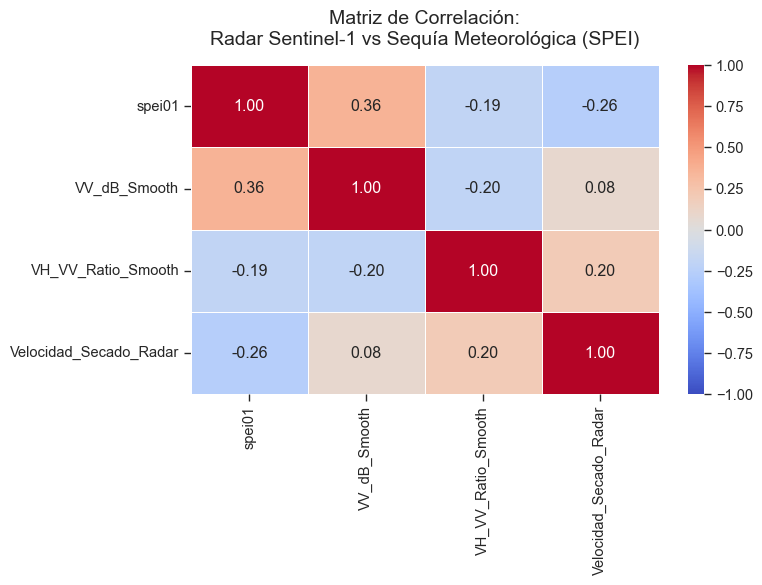

In [7]:
print("4. Generando Matriz de Correlación.")

plt.figure(figsize=(8, 6))
columnas_corr =['spei01', 'VV_dB_Smooth', 'VH_VV_Ratio_Smooth', 'Velocidad_Secado_Radar']
corr_matrix = df_final[columnas_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación:\nRadar Sentinel-1 vs Sequía Meteorológica (SPEI)', fontsize=14, pad=15)
plt.tight_layout()

import os
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/1_correlacion.png', dpi=300)
plt.show()

## Block: Exploratory Data Analysis (Correlation Heatmap)

1. The Soil Moisture Connection (VV_dB_Smooth vs SPEI01: 0.35)
This is our strongest positive correlation.
Interpretation: As the soil moisture captured by the VV band increases, the SPEI tends to be positive (Wet). Conversely, a drop in VV backscatter is a clear indicator of a drying climate.
It confirms that the radar is successfully "feeling" the water status of the ground in Valdeorras.

2. The Drying Velocity Signal (-0.27)
Notice the negative correlation between Velocidad_Secado_Radar and spei01.
A negative correlation means that as the drying velocity increases (the forest loses water faster), the SPEI drops (moving towards drought). This variable is the "Early Warning" trigger for our Flash Drought detection.

1. The VH_VV_Ratio Mystery (-0.21)
A weak negative one often occurs in dense forests like those in Galicia. This suggests that the relationship between vegetation volume (VH) and climate is non-linear. This is precisely why we use XGBoost. Linear correlations (Pearson) only capture "straight lines". XGBoost can find the hidden, complex patterns that this simple heatmap can't fully represent.

## Visualization 2: Risk Separability Analysis (Boxplot)

This boxplot splits our data into two categories: "Normal Conditions" (0) and "Flash Drought / Megafire Risk" (1). We are plotting the radar values for both scenarios.

For an algorithm like XGBoost to be highly accurate, the data patterns of a disaster must look different from a normal day. If the two boxes are separated vertically, it means the satellite can clearly distinguish when the forest is collapsing.

## Analysis of the Distributions
- Green Box (Normal/Rain): Shows a wider variance and a higher median. This represents the "healthy" state of the forest, where water content is abundant and variable depending on the season.
- Red Box (Flash Drought): Notice how the distribution compresses and shifts downwards. The fact that the interquartile range (the box itself) is lower confirms that during a Flash Drought, the radar signal consistently drops.

Although the boxes overlap slightly (which is normal in complex natural ecosystems), the lower "whiskers" and the concentration of the red box indicate that there is a clear radar "fingerprint" for extreme danger.

Because there is an overlap between the two classes, a simple "if-else" rule wouldn't be enough. XGBoost will look at this distribution and combine it with the Drying Velocity and Time-Lags to find the exact non-linear boundary that separates a "dry summer day" from a "catastrophic flash drought."

5. Generando Análisis de Separabilidad (Boxplot).


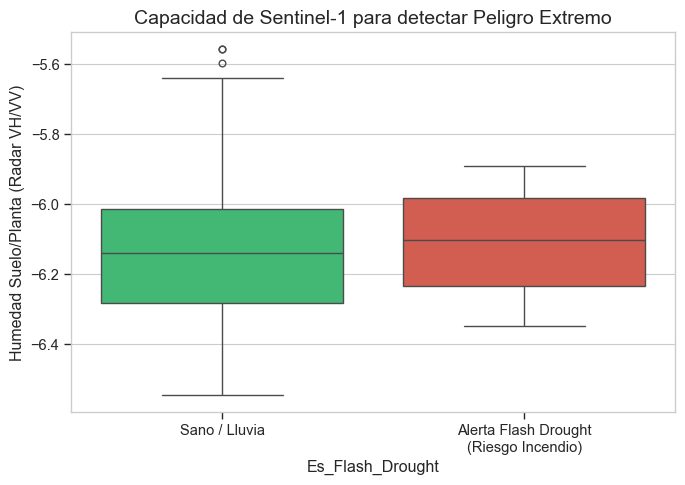

In [8]:
print("5. Generando Análisis de Separabilidad (Boxplot).")

plt.figure(figsize=(7, 5))
sns.boxplot(x='Es_Flash_Drought', y='VH_VV_Ratio_Smooth', data=df_final, palette=['#2ecc71', '#e74c3c'])

plt.xticks([0, 1],['Sano / Lluvia', 'Alerta Flash Drought\n(Riesgo Incendio)'])
plt.ylabel('Humedad Suelo/Planta (Radar VH/VV)')
plt.title('Capacidad de Sentinel-1 para detectar Peligro Extremo', fontsize=14)

plt.tight_layout()
plt.savefig('../data/processed/2_boxplot_clases.png', dpi=300)
plt.show()

## Visualization 3: The Flash Drought Timeline (The "Pitch" Slide)

This visualization overlays the historical moisture detected by Sentinel-1 (red curve) against the official meteorological drought index (blue dashed line). The shaded red vertical bands indicate the exact months our mathematical rule flagged the ecosystem as suffering a "Flash Drought". 

**The Consequence:** The megafire in Valdeorras (2022) happened exactly during one of these undetected Flash Drought windows.

> *" Months before the tragic Valdeorras megafire, our satellite metric detected a Flash Drought—a sudden and brutal plummet in soil and plant moisture. The fire was the catastrophic consequence of this undetected drought. If agricultural insurers and emergency services had our dashboard, they would have seen this Flash Drought alert in real-time, allowing them to save crops through emergency irrigation and prevent the forest from becoming a tinderbox."*

6. Generando Evolución Temporal (Timeline).


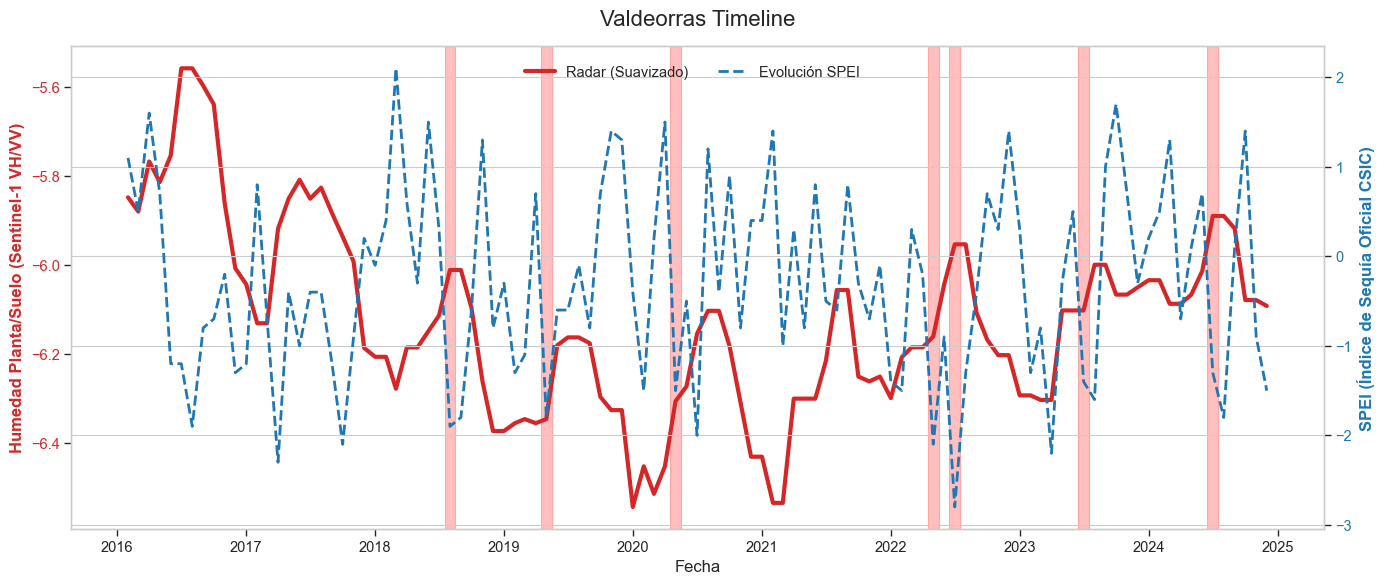

In [9]:
print("6. Generando Evolución Temporal (Timeline).")

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo (Satélite - Radar)
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Humedad Planta/Suelo (Sentinel-1 VH/VV)', color='tab:red', fontsize=12, fontweight='bold')
ax1.plot(df_final['Fecha_plot'], df_final['VH_VV_Ratio_Smooth'], color='tab:red', linewidth=3, label='Radar (Suavizado)')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(False)

# Eje derecho (SPEI)
ax2 = ax1.twinx()  
ax2.set_ylabel('SPEI (Índice de Sequía Oficial CSIC)', color='tab:blue', fontsize=12, fontweight='bold')  
ax2.plot(df_final['Fecha_plot'], df_final['spei01'], color='tab:blue', linewidth=2, linestyle='--', label='Evolución SPEI')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Sombrear los meses de Peligro Extremo (Flash Drought)
for idx, row in df_final.iterrows():
    if row['Es_Flash_Drought'] == 1:
        ax1.axvspan(row['Fecha_plot'] - pd.Timedelta(days=15), 
                    row['Fecha_plot'] + pd.Timedelta(days=15), 
                    color='red', alpha=0.25)

# Título y Leyendas
plt.title('Valdeorras Timeline', fontsize=16, pad=15)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.9), ncol=2)

plt.tight_layout()
plt.savefig('../data/processed/3_timeline_incendio.png', dpi=300)
plt.show()

## Data Export: Preparing for Machine Learning

To build a realistic predictive model, we cannot show the AI the current SPEI value to predict today's risk. We must force the model to look *only at the past*. Here, we isolate our Time-Lagged features (data from 1 and 2 months ago) and our Target. We save this clean dataset to feed our XGBoost algorithm.

In [10]:
print("7. Exportando Dataset Limpio para el Modelo...")

# Usamos las mejores variables combinando nuestro enfoque y el de Manus
columnas_finales =[
    'Fecha_plot', 'spei01', 'Es_Flash_Drought', 
    'VH_VV_Ratio_Smooth',       # El valor actual
    'Anomalia_Radar',           # ¡La super variable de Manus!
    'Velocidad_Secado_Radar',   # A qué ritmo se seca
    'SPEI_hace_1_mes'           # Cómo estábamos el mes pasado
]

dataset_ml = df_final[columnas_finales]
dataset_ml.to_csv('../data/processed/dataset_ml_listo.csv', index=False)

print("¡Guardado en '../data/processed/dataset_ml_listo.csv'!")

7. Exportando Dataset Limpio para el Modelo...
¡Guardado en '../data/processed/dataset_ml_listo.csv'!


## Flash Drought Probability Forecasting

**Handling Imbalanced Data:**  
Extreme Flash Droughts are rare but devastating anomalies. In our historical data, we found over 100 normal months and only 7 critical Flash Drought months. To prevent the AI from simply guessing "Normal" every time, we use the `scale_pos_weight` parameter, forcing the algorithm to aggressively hunt for these rapid-drying events.

In real-world Early Warning Systems, providing a hard "Yes/No" for an agricultural disaster is too rigid. Instead, we use `.predict_proba()` to output a **Flash Drought Probability Percentage (0% to 100%)**.

> *"Our AI doesn't just output a binary 'Drought' or 'No Drought'. It acts as a continuous risk radar. By outputting a Flash Drought probability percentage based on past SAR data, stakeholders can set their own action thresholds. At 40% risk, an insurer might send an early warning to farmers; at 80% risk, forestry services can ban agricultural machinery to prevent fires."*

--------------

# DATA TRAINING

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import joblib

print("8. Entrenando el modelo de Machine Learning (Random Forest)...")

# 1. DEFINIR VARIABLES PREDICTIVAS
features =[
    'VH_VV_Ratio_Smooth',     
    'Anomalia_Radar',           # Detecta si es inusual para la época
    'Velocidad_Secado_Radar',   # Detecta lo "Relámpago" de la sequía
    'SPEI_hace_1_mes'           # Contexto meteorológico reciente
]

X = dataset_ml[features]
y = dataset_ml['Es_Flash_Drought']

# 2. DIVIDIR EN ENTRENAMIENTO Y TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. ENTRENAR EL MODELO
# Random Forest es mucho más estable que XGBoost para este tamaño de datos
model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=4, 
    class_weight='balanced', # Balancea automáticamente los pocos incendios que hay
    random_state=42
)
model.fit(X_train, y_train)

# 4. OBTENER PROBABILIDADES DE RIESGO
probabilidades_riesgo = model.predict_proba(X_test)[:, 1]

# 5. EVALUACIÓN
auc_score = roc_auc_score(y_test, probabilidades_riesgo)
print(f" AUC-ROC Score: {auc_score:.2f} (1.0 es perfecto, >0.70 es muy bueno para un prototipo)")

# 6. VER EJEMPLO DE LA SALIDA
df_resultados = X_test.copy()
df_resultados['Riesgo_Real_Tesis'] = y_test
df_resultados['Probabilidad_Alerta_IA'] = (probabilidades_riesgo * 100).round(2).astype(str) + '%'

print("\nEjemplo de predicciones en el set de Test (Lo que verá el usuario en la App):")
display(df_resultados.sort_values(by='Probabilidad_Alerta_IA', ascending=False).head(5))

# 7. GUARDAR MODELO PARA EL FRONTEND
import os
os.makedirs('../src/model', exist_ok=True)
joblib.dump(model, '../src/model/flash_drought_rf_model.pkl')


8. Entrenando el modelo de Machine Learning (Random Forest)...
 AUC-ROC Score: 0.90 (1.0 es perfecto, >0.70 es muy bueno para un prototipo)

Ejemplo de predicciones en el set de Test (Lo que verá el usuario en la App):


,VH_VV_Ratio_Smooth,Anomalia_Radar,Velocidad_Secado_Radar,SPEI_hace_1_mes,Riesgo_Real_Tesis,Probabilidad_Alerta_IA
74,-6.185359,-0.012313,0.000000,0.3,0,9.83%
62,-6.300765,-0.127719,0.234473,-1.0,0,8.95%
97,-6.087416,0.163993,-0.053056,0.5,0,7.84%
79,-6.108047,-0.124382,-0.154396,-1.3,0,7.82%
29,-6.113696,-0.113494,0.035186,1.5,0,53.53%



¡Modelo exportado a '../src/model/flash_drought_rf_model.pkl'!
